# E17 — The Arabic Evaluation Gap

> **Enrichment — not examinable.** The official unit content is in `examples/`. This lesson exists to connect what you just learned to how the field works in 2026.

## 📚 Learning Objectives

By completing this notebook, you will:
- Measure the **UTF-8 byte cost** of Arabic against English — a penalty that exists before any model is chosen
- Train a **BPE tokenizer** on this repository's own English text and measure its **fertility** on English, Modern Standard Arabic, and a Saudi dialectal rendering of the same sentences
- Run the experiment that settles the argument: grow the vocabulary 32× and watch English fertility fall by half while Arabic does not move at all
- Segment Arabic clitics and show, from a parallel corpus, where the "missing" words went
- Measure the **dialect gap at the tokenizer level**: what share of dialect word types are unseen in an MSA vocabulary
- State what the published Arabic benchmarks (Absher, QIMMA, and the 2025 survey) found, and what that means for a project built in Saudi Arabia

## 🔗 Where this fits

**Builds on:** Course 07 — Unit 5, lesson 01 `examples/01_bias_detection.ipynb`, which walks through the
logic of a bias audit on *simulated* association scores and says so openly. This notebook does the opposite
kind of audit: the numbers are all real and measured here, and what they measure is a bias that is not in a
model's weights at all — it is arithmetic in the pipeline, present before training starts. It also builds
directly on Course 07 — Unit 2, lesson 01 `examples/01_advanced_tokenization.ipynb`, which introduced
subword tokenization, named **fertility**, and warned that suffix-stripping stemmers assume a morphology
Arabic does not have. Here you measure both of those claims instead of reading them. Course 06 (AIAT 116) —
Unit 2 supplies the fairness vocabulary this lesson uses.

**Used later in:** Course 10 (AIAT 124) — Unit 4, where regulatory and ethical obligations attach to
generative systems, and Course 12 (AIAT 126), where any Arabic-facing graduation project has to say how it
will be evaluated — and "we used an English benchmark translated into Arabic" is an answer this notebook
should make you unwilling to give.

## 🌍 Why this matters: the benchmark that found the gap, and the benchmark that checked the benchmarks

Arabic is the first language of every trainee reading this and the working language of the organisations you
will build systems for. It is also, in the machine-learning pipeline, a second-class citizen at three
separate layers — and only one of those layers is the model.

**Layer 1: the tokenizer.** Al-Monef, Alhuzali, Alturayeif and Alasmari built **Absher**, a benchmark of
"over 18,000 multiple-choice questions spanning six distinct categories: Meaning, True/False,
Fill-in-the-Blank, Contextual Usage, Cultural Interpretation, and Location Recognition", drawn from dialectal
words, phrases and proverbs collected across Saudi regions. Evaluating state-of-the-art multilingual and
Arabic-specific models, they report "notable performance gaps, particularly in tasks requiring cultural
inference or contextual understanding", and conclude with "the urgent need for dialect-aware training and
culturally aligned evaluation methodologies"
([arXiv:2507.10216](https://arxiv.org/abs/2507.10216)).

**Layer 2: the benchmarks themselves.** Alzubaidi et al. surveyed 40+ Arabic evaluation benchmarks and named
three gaps that recur across them: "limited temporal evaluation, insufficient multi-turn dialogue assessment,
and **cultural misalignment in translated datasets**"
([arXiv:2510.13430](https://arxiv.org/abs/2510.13430)). That last phrase is the one to remember: a benchmark
produced by translating an English test set inherits English assumptions about what is worth asking.

**Layer 3: nobody was checking layer 2.** In 2026, AlQadi et al. built **QIMMA**, an Arabic leaderboard whose
design premise is that the benchmarks must be validated *before* they are used to rank models. Rather than
"aggregating existing resources as-is", QIMMA "applies a multi-model assessment pipeline combining automated
LLM judgment with human review to surface and resolve systematic quality issues in well-established Arabic
benchmarks before evaluation", producing a curated suite of over 52,000 samples "grounded predominantly in
native Arabic content" ([arXiv:2604.03395](https://arxiv.org/abs/2604.03395)).

And the constructive side: Bari et al.'s **ALLaM** showed that "second-language acquisition via **vocabulary
expansion** and pretraining on a mixture of Arabic and English text can steer a model towards a new language
(Arabic) without any catastrophic forgetting in the original language", reaching state-of-the-art on MMLU
Arabic, ACVA and Arabic Exams ([arXiv:2407.15390](https://arxiv.org/abs/2407.15390)). *Vocabulary expansion*
is a tokenizer intervention. Part 3 of this notebook is where you find out why it was necessary.

**What goes wrong without this lesson.** A team builds an Arabic customer-service assistant on an
English-first stack, prices it per token, and discovers in production that the same conversation costs several
times what the English pilot cost, that half the context window is gone, and that the model's Arabic answers
degrade on exactly the dialectal input real customers use. None of that appears in an accuracy number. All of
it is measurable in advance, in about five seconds, with the code below.

## 📥 Inputs & 📤 Outputs

**Inputs:** two local sources, no downloads, no network, no random numbers.

- `assets/arabic_parallel_sample.tsv` — **40 short sentences in three parallel columns**: Modern Standard
  Arabic, a Saudi dialectal rendering of the same meaning, and an English gloss.
- **Every Markdown file in this repository** — a few hundred files and roughly 180,000 English word tokens —
  used as a realistic English training corpus for the tokenizer. The exact counts are printed by the cell
  that loads them, because they change as the repository does.

> ### 🏷️ Honest label — what the Arabic sample is and is not
> The sample was **written by the lesson author** for this lesson. It is not a scraped, licensed or
> published corpus. Forty sentences are enough to make tokenizer arithmetic visible and nowhere near enough
> to estimate anything about Arabic in general. The dialect column is *one* rendering, leaning Najdi/Hijazi;
> Saudi Arabia has several major dialect regions and treating one as "the" Saudi dialect is precisely the
> error Absher was built to expose. `assets/README.md` repeats all of this. **No language model is run
> anywhere in this notebook**; every benchmark result in Part 6 is a published claim with its citation.

**Outputs:** a byte-cost table; fertility for three tokenizers across three languages; a vocabulary-size
sweep with a chart; a clitic segmentation with its failures shown; an MSA-versus-dialect out-of-vocabulary
rate; and a labelled read-only summary of the published Arabic benchmark findings.

## Part 1: The Cost That Exists Before Any Model

Start below the tokenizer, at the bytes. UTF-8 encodes the Latin alphabet in **one** byte per character and
the Arabic block in **two**. Every modern tokenizer that meets an unfamiliar script falls back to bytes, so
this is the floor: the worst case a byte-level model can do, and the thing that is true of Arabic before
anybody chooses a model, a vocabulary, or a vendor.

In [1]:
# WHAT: load the parallel sample and measure raw size - characters, UTF-8 bytes, whitespace words -
#       for the same 40 meanings expressed in English, MSA and a Saudi dialect.
# WHY:  before blaming a model, measure the substrate. Two bytes per Arabic character is not a
#       modelling choice; it is the encoding, and everything downstream inherits it.
import re
import collections
from pathlib import Path
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    """Walk UP from the working directory until we see the course folders.

    WHY: this is what makes the notebook portable. It resolves the same whether the kernel
    started in this folder, at the repository root, or anywhere between - no '../../..'.
    Part 2 of this lesson trains a tokenizer on this repository's own Markdown, so unlike a
    dataset notebook this one genuinely needs the clone on disk; the message below says so.
    """
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    raise RuntimeError(
        f"No AI Diploma repository above {start}.\n"
        "This lesson's corpus IS this repository's Markdown, so it needs the repository on "
        "disk - a single downloaded data file would not do. Get it with:\n"
        "    git clone --depth 1 https://github.com/A-Alwabel/AI-Diploma-Program\n"
        "then open this notebook from inside the clone. On Google Colab, run that clone in a "
        "cell first and %cd into it, then re-run this cell."
    )

REPO = find_repo_root(Path.cwd())
ASSETS = REPO / "Course 07/unit5-applications-ethics/enrichment/assets"

sample = pd.read_csv(ASSETS / "arabic_parallel_sample.tsv", sep="\t", dtype=str)
LANGUAGES = {"english": sample["english"].tolist(),
             "MSA": sample["msa"].tolist(),
             "dialect": sample["dialect"].tolist()}

def words_of(text):
    """Whitespace words - the unit a human counts, and the denominator of fertility."""
    return [w for w in re.split(r"\s+", text.strip()) if w]

def strip_punctuation(word):
    """Keep letters and Arabic script; drop punctuation so it does not distort the counts."""
    return re.sub(r"[^\w\u0600-\u06FF']", "", word)

rows = []
for name, texts in LANGUAGES.items():
    tokens = [strip_punctuation(w) for t in texts for w in words_of(t)]
    tokens = [w for w in tokens if w]
    rows.append({
        "language": name,
        "sentences": len(texts),
        "words": len(tokens),
        "characters": sum(len(w) for w in tokens),
        "UTF-8 bytes": sum(len(w.encode("utf-8")) for w in tokens),
        "bytes / word": sum(len(w.encode("utf-8")) for w in tokens) / len(tokens),
    })
size_table = pd.DataFrame(rows)
print("The same 40 meanings, expressed three ways:\n")
print(size_table.to_string(index=False, float_format=lambda v: f"{v:.2f}"))

en, msa = size_table.iloc[0], size_table.iloc[1]
print(f"\nMSA uses {msa['words'] / en['words']:.2f}x the words of the English gloss "
      f"but {msa['UTF-8 bytes'] / en['UTF-8 bytes']:.2f}x the bytes.")
print(f"Per word: {msa['bytes / word']:.2f} bytes for MSA against {en['bytes / word']:.2f} for English "
      f"- a factor of {msa['bytes / word'] / en['bytes / word']:.2f}.")
print("\nThat factor is the encoding, not the model. It is the floor every byte-level fallback lands on.")

The same 40 meanings, expressed three ways:

language  sentences  words  characters  UTF-8 bytes  bytes / word
 english         40    239        1017         1017          4.26
     MSA         40    161         737         1474          9.16
 dialect         40    141         648         1296          9.19

MSA uses 0.67x the words of the English gloss but 1.45x the bytes.
Per word: 9.16 bytes for MSA against 4.26 for English - a factor of 2.15.

That factor is the encoding, not the model. It is the floor every byte-level fallback lands on.


## Part 2: Fertility — Tokens per Word, Measured

**Fertility** is the number of tokens a tokenizer produces per whitespace word. It sets three things at once:
how much of the context window your document consumes, how long generation takes, and — on a metered API —
what you are charged.

To measure it honestly we need a real tokenizer trained on a real corpus. We build one: **byte-pair encoding**
(Sennrich, Haddow & Birch, 2016) trained on **every Markdown file in this repository** — roughly 180,000
English word tokens of ordinary technical prose. That is exactly how a commercial English-first tokenizer comes to exist:
somebody trains BPE on a large English-dominant corpus, and whatever is not in that corpus gets no vocabulary.

We then compare three tokenizers on the same sentences:

| tokenizer | what it does | fertility on English |
|---|---|---|
| **whitespace** | splits on spaces | 1.00 by definition — the reference |
| **BPE (English corpus)** | merges frequent character pairs learned from the repo's text | measured below |
| **UTF-8 bytes** | the fallback every real tokenizer reaches for on unknown script | measured below |

In [2]:
# WHAT: train byte-pair encoding from scratch on the repository's English Markdown.
# WHY:  BPE is 40 lines and it is the whole reason a language can be expensive. Reading those lines
#       is how you understand that the tokenizer has no idea what a language is - it only knows
#       which character pairs were frequent in the text it was shown.
markdown_files = [p for p in sorted(REPO.glob("**/*.md")) if ".venv" not in str(p)]
corpus_text = "\n".join(p.read_text(encoding="utf-8", errors="ignore") for p in markdown_files)
english_words = re.findall(r"[A-Za-z']+", corpus_text.lower())
ENGLISH_FREQS = collections.Counter(english_words)

arabic_chars_in_corpus = len(re.findall(r"[\u0600-\u06FF]", corpus_text))
print(f"training corpus: {len(markdown_files)} Markdown files from this repository")
print(f"                 {len(corpus_text):,} characters, of which {arabic_chars_in_corpus:,} are Arabic "
      f"({arabic_chars_in_corpus / len(corpus_text):.2%})")
print(f"                 {len(english_words):,} English word tokens, {len(ENGLISH_FREQS):,} distinct types")
print(f"                 Arabic word tokens reaching the BPE trainer: 0")
print()
print("Read those last two lines together. The corpus is not purely English - it contains "
      f"{arabic_chars_in_corpus:,} Arabic")
print("characters. They are discarded one line above by the pre-tokenization regex [A-Za-z']+, which")
print("keeps Latin letters and nothing else. That regex, not the corpus, is where Arabic leaves the")
print("pipeline - and a regex exactly like it sits at the front of most English-first NLP code.")

def train_bpe(word_freqs, num_merges):
    """Learn `num_merges` byte-pair merges from a word -> frequency table."""
    words = [tuple(list(w) + ["</w>"]) for w in word_freqs]     # </w> marks the end of a word
    freqs = list(word_freqs.values())
    pair_counts = collections.Counter()
    pair_locations = collections.defaultdict(set)               # pair -> which words contain it
    for i, symbols in enumerate(words):
        for j in range(len(symbols) - 1):
            pair_counts[(symbols[j], symbols[j + 1])] += freqs[i]
            pair_locations[(symbols[j], symbols[j + 1])].add(i)

    merges = []
    for _ in range(num_merges):
        if not pair_counts:
            break
        best, count = pair_counts.most_common(1)[0]
        if count < 2:                       # nothing left that occurs more than once
            break
        merges.append(best)
        joined = best[0] + best[1]
        for i in list(pair_locations[best]):            # only touch words that contain the pair
            symbols = words[i]
            for j in range(len(symbols) - 1):           # withdraw this word's old pair counts
                p = (symbols[j], symbols[j + 1])
                pair_counts[p] -= freqs[i]
                if pair_counts[p] <= 0:
                    del pair_counts[p]
                pair_locations[p].discard(i)
            merged, j = [], 0
            while j < len(symbols):
                if j < len(symbols) - 1 and symbols[j] == best[0] and symbols[j + 1] == best[1]:
                    merged.append(joined); j += 2
                else:
                    merged.append(symbols[j]); j += 1
            symbols = tuple(merged)
            words[i] = symbols
            for j in range(len(symbols) - 1):           # re-add the new ones
                p = (symbols[j], symbols[j + 1])
                pair_counts[p] += freqs[i]
                pair_locations[p].add(i)
        pair_locations.pop(best, None)
        pair_counts.pop(best, None)
    return merges

def make_encoder(merges):
    """Apply the learned merges to any word, most-frequent merge first."""
    rank = {pair: i for i, pair in enumerate(merges)}
    cache = {}
    def encode(word):
        if word in cache:
            return cache[word]
        symbols = list(word) + ["</w>"]
        while len(symbols) > 1:
            best_rank, at = min((rank.get((symbols[k], symbols[k + 1]), 10 ** 9), k)
                                for k in range(len(symbols) - 1))
            if best_rank == 10 ** 9:        # no learned merge applies: we are done
                break
            symbols[at:at + 2] = [symbols[at] + symbols[at + 1]]
        cache[word] = symbols
        return symbols
    return encode

bpe_merges = train_bpe(ENGLISH_FREQS, 8000)
encode_bpe = make_encoder(bpe_merges)
print(f"\nlearned {len(bpe_merges):,} merges. The first ten, in order of frequency:")
print("  " + ", ".join(f"{a}+{b}" for a, b in bpe_merges[:10]))

training corpus: 387 Markdown files from this repository
                 1,502,170 characters, of which 1,863 are Arabic (0.12%)
                 185,793 English word tokens, 7,032 distinct types
                 Arabic word tokens reaching the BPE trainer: 0

Read those last two lines together. The corpus is not purely English - it contains 1,863 Arabic
characters. They are discarded one line above by the pre-tokenization regex [A-Za-z']+, which
keeps Latin letters and nothing else. That regex, not the corpus, is where Arabic leaves the
pipeline - and a regex exactly like it sits at the front of most English-first NLP code.



learned 8,000 merges. The first ten, in order of frequency:
  s+</w>, e+</w>, i+n, t+</w>, o+n, t+i, d+</w>, r+e, o+r, e+r


In [3]:
# WHAT: measure fertility for all three tokenizers on all three languages.
# WHY:  one table, and the argument is over. Note that the two Arabic columns are nearly identical -
#       the penalty is about SCRIPT, not about which variety of Arabic you write.
def fertility(texts, tokenize):
    """Average tokens produced per whitespace word."""
    total_tokens = total_words = 0
    for text in texts:
        for word in words_of(text):
            clean = strip_punctuation(word)
            if not clean:
                continue
            total_tokens += len(tokenize(clean))
            total_words += 1
    return total_tokens / total_words

tokenizers = {
    "whitespace": lambda w: [w],
    "BPE (English corpus, 8k merges)": lambda w: encode_bpe(w.lower()),
    "UTF-8 bytes": lambda w: list(w.encode("utf-8")),
}

fert = pd.DataFrame(
    {name: {lang: fertility(texts, fn) for lang, texts in LANGUAGES.items()}
     for name, fn in tokenizers.items()}
).T
print("Fertility - tokens produced per whitespace word (lower is cheaper):\n")
print(fert.to_string(float_format=lambda v: f"{v:6.2f}"))

bpe_row = fert.loc["BPE (English corpus, 8k merges)"]
byte_row = fert.loc["UTF-8 bytes"]
print(f"\nPer word: an Arabic word costs {bpe_row['MSA']:.2f} tokens against {bpe_row['english']:.2f} "
      f"for English - a factor of {bpe_row['MSA'] / bpe_row['english']:.2f}.")

# Per WORD overstates the bill, because Arabic says the same thing in fewer words. The number that
# reaches an invoice is tokens for the whole sample - the same 40 meanings, both languages.
def total_tokens(texts, tokenize):
    return sum(len(tokenize(strip_punctuation(w)))
               for t in texts for w in words_of(t) if strip_punctuation(w))

tokens_en = total_tokens(LANGUAGES["english"], lambda w: encode_bpe(w.lower()))
tokens_msa = total_tokens(LANGUAGES["MSA"], lambda w: encode_bpe(w.lower()))
print(f"\nPer meaning (all 40 sentences, both languages, same content):")
print(f"  english : {tokens_en:,} tokens")
print(f"  MSA     : {tokens_msa:,} tokens   -> {tokens_msa / tokens_en:.2f}x")
print(f"  On a per-token contract that is the multiplier on your bill, and on a 4,000-token context")
print(f"  window it means {4000 / (tokens_msa / 40):.0f} of these sentences fit in Arabic against "
      f"{4000 / (tokens_en / 40):.0f} in English.")
print(f"\nMSA and dialect differ by only {abs(bpe_row['MSA'] - bpe_row['dialect']):.3f} tokens per word.")
print("The tokenizer does not know what a dialect is. It only knows which characters it has seen.")

Fertility - tokens produced per whitespace word (lower is cheaper):

                                 english    MSA  dialect
whitespace                          1.00   1.00     1.00
BPE (English corpus, 8k merges)     1.16   5.58     5.60
UTF-8 bytes                         4.26   9.16     9.19

Per word: an Arabic word costs 5.58 tokens against 1.16 for English - a factor of 4.81.

Per meaning (all 40 sentences, both languages, same content):
  english : 277 tokens
  MSA     : 898 tokens   -> 3.24x
  On a per-token contract that is the multiplier on your bill, and on a 4,000-token context
  window it means 178 of these sentences fit in Arabic against 578 in English.

MSA and dialect differ by only 0.018 tokens per word.
The tokenizer does not know what a dialect is. It only knows which characters it has seen.


## Part 3: The Experiment — Buy More Vocabulary and See Who Benefits

The standard answer to "our tokenizer is inefficient" is "use a bigger vocabulary". Let us find out who that
helps.

**Baseline.** BPE with **250** merges, trained on the repository's English Markdown.

**Change one thing.** The number of merges: 250 → 1,000 → 4,000 → 8,000. A 32-fold increase in learned
vocabulary. Same corpus, same algorithm, same evaluation sentences, same fertility measure.

**Re-run and read the numbers.** If the Arabic penalty were about "vocabulary size", it should shrink.

In [4]:
# WHAT: retrain BPE at four vocabulary budgets and measure fertility on all three languages each time.
# WHY:  this is the cell that ends the argument. Watch the English column and the Arabic columns move
#       differently - and note that "differently" understates it.
sweep_rows = []
for budget in (250, 1000, 4000, 8000):
    merges = train_bpe(ENGLISH_FREQS, budget)
    encode = make_encoder(merges)
    sweep_rows.append({
        "merges learned": len(merges),
        **{lang: fertility(texts, lambda w, e=encode: e(w.lower()))
           for lang, texts in LANGUAGES.items()},
    })
sweep = pd.DataFrame(sweep_rows)
print("Fertility as the English-trained vocabulary grows 32x:\n")
print(sweep.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

first, last = sweep.iloc[0], sweep.iloc[-1]
print(f"\nCONCLUSION SUPPORTED BY THESE NUMBERS:")
print(f"  english : {first['english']:.3f} -> {last['english']:.3f} tokens/word "
      f"({(last['english'] / first['english'] - 1):+.0%})")
print(f"  MSA     : {first['MSA']:.3f} -> {last['MSA']:.3f} tokens/word "
      f"({(last['MSA'] / first['MSA'] - 1):+.0%})")
print(f"  dialect : {first['dialect']:.3f} -> {last['dialect']:.3f} tokens/word "
      f"({(last['dialect'] / first['dialect'] - 1):+.0%})")
print(f"\n  Thirty-two times the vocabulary cut English cost roughly in half and did nothing at all for")
print(f"  Arabic - not a little, exactly nothing, to three decimal places. Every merge BPE learned was")
print(f"  a pair of Latin characters, because those were the only pairs in the corpus. The Arabic words")
print(f"  fall through to single characters no matter how large the vocabulary gets.")
print(f"\n  The penalty is not a property of Arabic. It is a property of the TRAINING CORPUS.")

Fertility as the English-trained vocabulary grows 32x:

 merges learned  english     MSA  dialect
            250    2.439   5.578    5.596
           1000    1.724   5.578    5.596
           4000    1.272   5.578    5.596
           8000    1.159   5.578    5.596

CONCLUSION SUPPORTED BY THESE NUMBERS:
  english : 2.439 -> 1.159 tokens/word (-52%)
  MSA     : 5.578 -> 5.578 tokens/word (+0%)
  dialect : 5.596 -> 5.596 tokens/word (+0%)

  Thirty-two times the vocabulary cut English cost roughly in half and did nothing at all for
  Arabic - not a little, exactly nothing, to three decimal places. Every merge BPE learned was
  a pair of Latin characters, because those were the only pairs in the corpus. The Arabic words
  fall through to single characters no matter how large the vocabulary gets.

  The penalty is not a property of Arabic. It is a property of the TRAINING CORPUS.


In [5]:
# WHAT: the addendum - put Arabic into the training corpus and re-measure on HELD-OUT Arabic sentences.
# WHY:  the previous cell says the corpus is the cause. This one checks the implication: if the corpus
#       is the cause, then adding Arabic to it should fix the fertility. Read the size caveat first.
train_split, test_split = sample.iloc[:30], sample.iloc[30:]
arabic_freqs = collections.Counter(
    strip_punctuation(w) for t in train_split["msa"] for w in words_of(t) if strip_punctuation(w))
arabic_merges = train_bpe(arabic_freqs, 400)
encode_arabic = make_encoder(arabic_merges)

print("!! SIZE CAVEAT, READ BEFORE THE NUMBERS !!")
print(f"   The Arabic 'corpus' here is {len(train_split)} sentences, {sum(arabic_freqs.values())} word "
      f"tokens, {len(arabic_freqs)} types.")
print(f"   BPE ran out of pairs occurring more than once after {len(arabic_merges)} merges.")
print("   That is a toy. The DIRECTION of the effect below is the lesson; the magnitude is not a")
print(f"   measurement of anything. Compare against the {len(english_words):,}-token English corpus above.\n")

held_out = test_split["msa"].tolist()
english_trained = fertility(held_out, lambda w: encode_bpe(w.lower()))
arabic_trained = fertility(held_out, lambda w: encode_arabic(w))
print(f"fertility on the {len(held_out)} HELD-OUT MSA sentences:")
print(f"  tokenizer trained on {len(english_words):,} English word tokens : {english_trained:.2f} tokens/word")
print(f"  tokenizer trained on {sum(arabic_freqs.values()):>7d} Arabic word tokens  : "
      f"{arabic_trained:.2f} tokens/word")
print(f"  reduction: {(1 - arabic_trained / english_trained):.0%}")
print(f"\n{sum(arabic_freqs.values())} words of Arabic in the training corpus bought a "
      f"{(1 - arabic_trained / english_trained):.0%} cut on text the tokenizer")
print("had never seen, against a corpus more than a thousand times larger in the other language.")
print("That is what ALLaM's 'vocabulary expansion' does, at a scale you can inspect line by line.")

!! SIZE CAVEAT, READ BEFORE THE NUMBERS !!
   The Arabic 'corpus' here is 30 sentences, 117 word tokens, 101 types.
   BPE ran out of pairs occurring more than once after 72 merges.
   That is a toy. The DIRECTION of the effect below is the lesson; the magnitude is not a
   measurement of anything. Compare against the 185,793-token English corpus above.

fertility on the 10 HELD-OUT MSA sentences:
  tokenizer trained on 185,793 English word tokens : 5.86 tokens/word
  tokenizer trained on     117 Arabic word tokens  : 3.86 tokens/word
  reduction: 34%

117 words of Arabic in the training corpus bought a 34% cut on text the tokenizer
had never seen, against a corpus more than a thousand times larger in the other language.
That is what ALLaM's 'vocabulary expansion' does, at a scale you can inspect line by line.


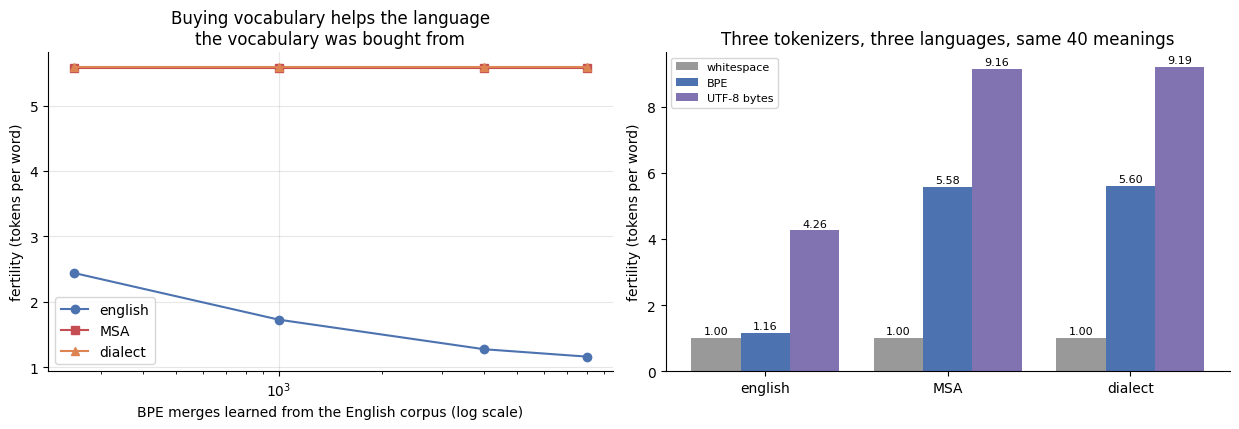

In [6]:
# WHAT: plot the sweep - the two lines that do not converge.
# WHY:  this chart is the argument in one image, and it is the image to put in front of anyone who
#       says "just use a bigger model".
import matplotlib.pyplot as plt        # the notebook kernel renders figures inline; no window is opened

fig, (axL, axR) = plt.subplots(1, 2, figsize=(12.5, 4.4))

for lang, colour, marker in (("english", "#4C72B0", "o"), ("MSA", "#C44E52", "s"),
                             ("dialect", "#DD8452", "^")):
    axL.plot(sweep["merges learned"], sweep[lang], marker + "-", color=colour, label=lang)
axL.set_xscale("log")
axL.set_xlabel("BPE merges learned from the English corpus (log scale)")
axL.set_ylabel("fertility (tokens per word)")
axL.set_title("Buying vocabulary helps the language\nthe vocabulary was bought from")
axL.legend(); axL.grid(alpha=0.3)
axL.spines[["top", "right"]].set_visible(False)

labels = list(LANGUAGES)
x = np.arange(len(labels)); width = 0.27
for offset, (name, colour) in zip((-width, 0, width),
                                  [("whitespace", "#999999"),
                                   ("BPE (English corpus, 8k merges)", "#4C72B0"),
                                   ("UTF-8 bytes", "#8172B2")]):
    values = [fert.loc[name, lang] for lang in labels]
    bars = axR.bar(x + offset, values, width, label=name.split(" (")[0], color=colour)
    for bar in bars:
        axR.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.12,
                 f"{bar.get_height():.2f}", ha="center", fontsize=8)
axR.set_xticks(x, labels)
axR.set_ylabel("fertility (tokens per word)")
axR.set_title("Three tokenizers, three languages, same 40 meanings")
axR.legend(fontsize=8); axR.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()

## 💬 Discuss

1. The sweep shows Arabic fertility unchanged to three decimal places across a 32× vocabulary increase. A
   colleague concludes "Arabic is just harder for computers". Using the numbers in this notebook, write the
   two-sentence correction — and say what evidence would be needed to support the original claim.
2. Your team is quoted a per-token price for an Arabic assistant. Using the fertility figures above, work out
   what the same conversation costs relative to its English equivalent, and decide: is the right response to
   negotiate the price, change the model, or change the input? Defend your choice with one of the numbers.
3. MSA and the dialect column differ by less than 0.02 tokens per word, yet Absher found large *accuracy*
   gaps between MSA and Saudi dialects. Both statements are true. Explain how — and say which layer of the
   stack the accuracy gap must live in, given that it is not the tokenizer.

## Part 4: Where the "Missing" Words Went

Look again at the Part 1 table. The English glosses use more whitespace words than the Arabic sentences do,
for the same meanings. Nothing was left out. Arabic **attaches** what English writes separately:
conjunctions, prepositions, the definite article, the future marker, and object pronouns all bind directly
to the word.

`وسنراجعها` is one whitespace word and five English ones: *and* + *will* + *review* + *we* + *it*.

Course 07, Unit 2 warned you that suffix-stripping stemmers assume a morphology Arabic does not have. Here we
build the clitic splitter such a pipeline needs, measure what it recovers, and — just as importantly — look
at where it is wrong.

In [7]:
# WHAT: a rule-based Arabic clitic splitter, applied to the MSA column, with the result compared
#       against the English gloss's word count.
# WHY:  the comparison is only possible because the corpus is PARALLEL. Same meanings, two
#       encodings of them - so the difference in word counts is real information, not an artifact.
PREFIX_CLITICS = ["وال", "بال", "كال", "فال", "لل", "ال", "و", "ف", "ب", "ك", "ل", "س"]
SUFFIX_CLITICS = ["ها", "هم", "هن", "كم", "كن", "نا", "ني", "ه", "ك"]
MIN_STEM = 3          # never strip a clitic if it would leave a stem shorter than this

def split_clitics(word, min_stem=MIN_STEM):
    """Peel attached prefixes and suffixes off an Arabic surface form. Deliberately simple."""
    prefixes, stem, suffixes = [], word, []
    changed = True
    while changed:
        changed = False
        for clitic in PREFIX_CLITICS:
            if stem.startswith(clitic) and len(stem) - len(clitic) >= min_stem:
                prefixes.append(clitic); stem = stem[len(clitic):]; changed = True; break
    changed = True
    while changed:
        changed = False
        for clitic in sorted(SUFFIX_CLITICS, key=len, reverse=True):
            if stem.endswith(clitic) and len(stem) - len(clitic) >= min_stem:
                suffixes.insert(0, clitic); stem = stem[:-len(clitic)]; changed = True; break
    return prefixes + [stem] + suffixes

msa_tokens = [strip_punctuation(w) for t in sample["msa"] for w in words_of(t)]
msa_tokens = [w for w in msa_tokens if w]
english_tokens = [w for t in sample["english"] for w in words_of(t)]
segmented = [split_clitics(w) for w in msa_tokens]
units = sum(len(s) for s in segmented)

print(f"MSA whitespace words                 : {len(msa_tokens)}")
print(f"MSA units after clitic splitting     : {units}   ({units / len(msa_tokens):.2f} per word)")
print(f"English whitespace words (same 40 meanings): {len(english_tokens)}")
print(f"\nBefore splitting, Arabic looks {1 - len(msa_tokens) / len(english_tokens):.0%} shorter than English.")
print(f"After splitting, the two counts are within "
      f"{abs(units - len(english_tokens)) / len(english_tokens):.1%} of each other.")
print("The words were never missing. They were glued on.\n")

print("Ten segmentations - six that behave, then three failures and one lucky escape:")
for word in ["والطريق", "التطبيق", "لحسابه", "بنراجع", "مساعدتي", "سنراجع",
             "بالسيرفر", "الإلكتروني", "هالبيانات", "وين"]:
    print(f"   {word:<12s} ->  {' + '.join(split_clitics(word))}")
print("\n  بالسيرفر  : a loanword; the splitter finds a 'س' prefix that is part of the stem.")
print("  الإلكتروني: 'ني' is a real pronoun suffix elsewhere, and part of the word here.")
print("  هالبيانات : 'هال' is a dialectal form of 'هذا ال' and is not in our prefix list at all.")
print("  وين       : correctly left alone - only because the minimum-stem rule blocked it.")
print("\nA rule list cannot tell a clitic from a coincidence. That is what morphological analysers")
print("(MADAMIRA, Farasa, CAMeL Tools) are for, and why Arabic NLP has needed them for decades.")

MSA whitespace words                 : 161
MSA units after clitic splitting     : 228   (1.42 per word)
English whitespace words (same 40 meanings): 239

Before splitting, Arabic looks 33% shorter than English.
After splitting, the two counts are within 4.6% of each other.
The words were never missing. They were glued on.

Ten segmentations - six that behave, then three failures and one lucky escape:
   والطريق      ->  وال + طريق
   التطبيق      ->  ال + تطبيق
   لحسابه       ->  ل + حساب + ه
   بنراجع       ->  ب + نراجع
   مساعدتي      ->  مساعدتي
   سنراجع       ->  س + نراجع
   بالسيرفر     ->  بال + س + يرفر
   الإلكتروني   ->  ال + إلكترو + ني
   هالبيانات    ->  هالبيانات
   وين          ->  وين

  بالسيرفر  : a loanword; the splitter finds a 'س' prefix that is part of the stem.
  الإلكتروني: 'ني' is a real pronoun suffix elsewhere, and part of the word here.
  هالبيانات : 'هال' is a dialectal form of 'هذا ال' and is not in our prefix list at all.
  وين       : correctly left a

## Part 5: The Dialect Gap, at the Only Layer We Can Measure Here

Part 2 showed that the *tokenizer* barely distinguishes MSA from dialect — both are Arabic script, both cost
about 5.6 tokens per word. So where does the dialect gap live?

One measurable part of it is **vocabulary coverage**. Build a lexicon from MSA text — which is what almost
every Arabic resource, corpus and benchmark is built from — and ask how much of real dialectal speech it
contains.

In [8]:
# WHAT: build a word-type lexicon from the MSA column and measure how much of the dialect column
#       it covers, both by type and by running token.
# WHY:  every system trained predominantly on MSA - which is most of them - inherits this number.
#       It is not about the model's reasoning; it is about whether the words were ever there.
def type_set(texts):
    out = set()
    for text in texts:
        for word in words_of(text):
            clean = strip_punctuation(word)
            if clean:
                out.add(clean)
    return out

msa_lexicon = type_set(sample["msa"])
dialect_types = type_set(sample["dialect"])
dialect_tokens = [strip_punctuation(w) for t in sample["dialect"] for w in words_of(t)]
dialect_tokens = [w for w in dialect_tokens if w]

unseen_types = sorted(dialect_types - msa_lexicon)
unseen_tokens = [w for w in dialect_tokens if w not in msa_lexicon]

print(f"MSA lexicon (word types)                    : {len(msa_lexicon)}")
print(f"dialect word types                          : {len(dialect_types)}")
print(f"dialect types absent from the MSA lexicon   : {len(unseen_types)}  "
      f"({len(unseen_types) / len(dialect_types):.0%})")
print(f"dialect running words absent from it        : {len(unseen_tokens)} of {len(dialect_tokens)}  "
      f"({len(unseen_tokens) / len(dialect_tokens):.0%})")

print("\nTwenty of the unseen forms, with what they correspond to:")
pairs = [("وش", "ما / what"), ("وين", "أين / where"), ("أبغى", "أريد / I want"),
         ("أروح", "أذهب / I go"), ("بكم", "كم سعر / how much"), ("ما أدري", "لا أعرف / I don't know"),
         ("بكرة", "غدا / tomorrow"), ("بعدين", "لاحقا / later"), ("زحمة", "مزدحم / crowded"),
         ("شوي", "قليلا / a little")]
for dialect_word, gloss in pairs:
    mark = "unseen" if dialect_word.split()[0] not in msa_lexicon else "in lexicon"
    print(f"   {dialect_word:<10s} = {gloss:<24s} [{mark}]")
print("   ... " + ", ".join(unseen_types[:12]))

print(f"\nThese are not rare words. They are how people ask where something is and what it costs.")
print(f"A system whose training data, evaluation set and lexicon are all MSA has never seen "
      f"{len(unseen_types) / len(dialect_types):.0%} of them.")

MSA lexicon (word types)                    : 132
dialect word types                          : 120
dialect types absent from the MSA lexicon   : 57  (48%)
dialect running words absent from it        : 62 of 141  (44%)

Twenty of the unseen forms, with what they correspond to:
   وش         = ما / what                [unseen]
   وين        = أين / where              [unseen]
   أبغى       = أريد / I want            [unseen]
   أروح       = أذهب / I go              [unseen]
   بكم        = كم سعر / how much        [unseen]
   ما أدري    = لا أعرف / I don't know   [in lexicon]
   بكرة       = غدا / tomorrow           [unseen]
   بعدين      = لاحقا / later            [unseen]
   زحمة       = مزدحم / crowded          [unseen]
   شوي        = قليلا / a little         [unseen]
   ... أبغى, أدري, أروح, أستريح, أكد, الأوراق, الإيميل, الباص, الحين, السر, الكبيرة, النت

These are not rare words. They are how people ask where something is and what it costs.
A system whose training data, evaluatio

## Part 6: The Half This Notebook Cannot Run — Measured Benchmark Gaps

> ### 📋 READ-ONLY COMPARISON — published claims, not measurements made here
> Evaluating an actual Arabic LLM is out of scope offline: it requires downloading model weights and a
> benchmark, neither of which this lesson has. **No language model was run at any point in this notebook.**
> Every result below is quoted from the cited paper. The measurements in Parts 1–5 are ours; the
> measurements in this table are not.

| work | year | what its authors report | id |
|---|---|---|---|
| **ALLaM** | 2024 | Arabic-and-English LLM series. "Second-language acquisition via **vocabulary expansion** and pretraining on a mixture of Arabic and English text can steer a model towards a new language (Arabic) without any catastrophic forgetting in the original language (English)." Reports state-of-the-art on MMLU Arabic, ACVA and Arabic Exams | [2407.15390](https://arxiv.org/abs/2407.15390) |
| **Absher** | 2025 | A Saudi-dialect benchmark: "over 18,000 multiple-choice questions spanning six distinct categories: Meaning, True/False, Fill-in-the-Blank, Contextual Usage, Cultural Interpretation, and Location Recognition", from dialectal words, phrases and proverbs across Saudi regions. Evaluating multilingual and Arabic-specific models, finds "notable performance gaps, particularly in tasks requiring cultural inference or contextual understanding" | [2507.10216](https://arxiv.org/abs/2507.10216) |
| **Arabic benchmark survey** | 2025 | First systematic review of Arabic LLM benchmarks: 40+ benchmarks in four categories (Knowledge, NLP Tasks, Culture and Dialects, Target-Specific). Identifies "limited temporal evaluation, insufficient multi-turn dialogue assessment, and **cultural misalignment in translated datasets**", and compares native collection, translation and synthetic generation as sourcing strategies | [2510.13430](https://arxiv.org/abs/2510.13430) |
| **QIMMA** | 2026 | An Arabic leaderboard built on benchmark *validation*: "a multi-model assessment pipeline combining automated LLM judgment with human review to surface and resolve systematic quality issues in well-established Arabic benchmarks **before** evaluation", yielding 52k+ curated samples "grounded predominantly in native Arabic content" | [2604.03395](https://arxiv.org/abs/2604.03395) |

### What this means for a project built here

Read those four rows next to your own measurements and five decisions fall out. These are the ones to write
into a project proposal in Course 12.

1. **Report fertility for your input language before you sign anything.** You computed it in five seconds. A
   per-token contract priced on an English pilot is mispriced for Arabic by roughly the factor you measured,
   and so is your context-window budget.
2. **Prefer a model whose tokenizer was trained with Arabic in the corpus.** Part 3 shows why a bigger
   vocabulary alone does not help; ALLaM's vocabulary expansion is the intervention that does.
3. **Never evaluate on a translated benchmark alone.** The 2025 survey names cultural misalignment in
   translated datasets as a recurring defect. A test set translated from English asks English questions in
   Arabic words.
4. **Test on the language your users actually speak.** Your users write `وش` and `وين`, not `ما` and `أين`.
   Part 5 measured 48% of dialect word types absent from an MSA lexicon on our sample; Absher measured the
   consequence on 18,000 real questions.
5. **Validate the benchmark before you trust the ranking.** That is QIMMA's entire contribution, and it is
   transferable: whatever you evaluate on, sample it, read it, and check that the questions are answerable
   and correctly keyed. This is the same discipline as Course 12, Unit 4 — a number you did not interrogate
   is not evidence.

## ✅ Summary

**What you actually did here** — every figure below was printed by the cells above:

- Measured the encoding floor: an Arabic word costs **9.16 UTF-8 bytes against 4.26** for English — a factor
  of **2.15**, fixed by the encoding, before any model exists
- Trained BPE from scratch on **every Markdown file in this repository** (roughly 180,000 English word
  tokens) and measured fertility: **1.16 tokens/word for English, 5.58 for MSA, 5.60 for dialect** — a factor
  of **4.81** per word, and **3.24×** for the whole 40-sentence sample once Arabic's shorter word count is
  taken into account
- Grew that vocabulary **32×** and watched English fertility fall **52%** while MSA and dialect moved by
  **+0%** — to three decimal places, nothing — so the penalty is a property of the training corpus, not of Arabic
- Put 117 words of Arabic into the training corpus and cut held-out Arabic fertility by **34%**, which is
  vocabulary expansion at 1/1000 scale
- Segmented Arabic clitics and showed the "missing" words: **161 MSA whitespace words become 228 units**
  against **239** English words for the same 40 meanings — within 4.6%
- Measured the dialect gap where it is measurable offline: **48% of dialect word types** are absent from an
  MSA lexicon built on the same content

**The one sentence to keep:** *the Arabic penalty in an English-first pipeline is arithmetic, not difficulty*
— it is set by what was in the tokenizer's training corpus, it is measurable in seconds, and no amount of
model scale removes it.

**Do this in your own project.** Before you choose a model or sign a per-token contract, run Part 2 on a
sample of your real input. If fertility is above about 2, you are paying a tax you can see, and you now know
which question to ask the vendor.

## ⚠️ Where this breaks

**Forty sentences are not a corpus, and one author is not a population.** Every number computed from
`assets/arabic_parallel_sample.tsv` describes that file. The fertility *ratio* is robust — it follows from
the script and the training corpus, and would survive a hundred times more text — but the absolute figures,
the 48% out-of-vocabulary rate and the 1.42 units per word are all sample statistics from a small,
author-written sample. Do not quote them as facts about Arabic. Re-run the code on your own text; that takes
under a minute and gives you a number you can defend.

**The dialect column is one rendering.** Saudi Arabia contains Najdi, Hijazi, Eastern and Southern dialect
regions with substantial differences, and the sentences here lean Najdi/Hijazi. Absher's design — dialectal
words, phrases and proverbs sourced from *various regions* — exists precisely because a single rendering is
not representative.

**Our BPE is a teaching implementation.** No byte-level fallback, no pre-tokenization rules, no special
tokens, no normalisation of Arabic orthography (`أ` / `ا` / `إ` are distinct characters to it, as are the
`ة` / `ه` pair) — all of which real tokenizers handle and all of which change fertility. Production
tokenizers are also byte-level, so their true Arabic worst case is the UTF-8 row, not the BPE row.

**The clitic splitter is a rule list, and Part 4 shows it failing.** `بالسيرفر`, `الإلكتروني` and
`هالبيانات` were all handled wrongly, in three different ways — one over-split, one mis-split, one missed
entirely — and nothing in the output signals it. A real pipeline needs a morphological analyser with a
lexicon and a disambiguator. Treat our 1.42 units per word as an approximation with visible errors in it.

**And Parts 1–5 measure the tokenizer, which is the layer that matters least for accuracy.** Fertility sets
cost, latency and context consumption. It does not explain why a model answers a Saudi proverb incorrectly —
Part 2 found MSA and dialect fertility differing by 0.018 tokens per word while Absher found large accuracy
gaps between them. That gap lives in the training data, the instruction tuning and the evaluation set, none
of which this notebook can touch. Measuring the layer you *can* measure is a good habit; mistaking it for the
whole problem is not.

## 📚 References

Arabic language models and their evaluation:

1. Bari, M. S., Alnumay, Y., Alzahrani, N. A., Alotaibi, N. M., Alyahya, H. A., et al. (2024). *ALLaM: Large Language Models for Arabic and English*. [arXiv:2407.15390](https://arxiv.org/abs/2407.15390) — vocabulary expansion and Arabic/English mixture pretraining; the constructive answer to Part 3.
2. Al-Monef, R., Alhuzali, H., Alturayeif, N., & Alasmari, A. (2025). *From Words to Proverbs: Evaluating LLMs Linguistic and Cultural Competence in Saudi Dialects with Absher*. [arXiv:2507.10216](https://arxiv.org/abs/2507.10216) — the 18,000-question Saudi-dialect benchmark and the cultural-inference gap it measures.
3. Alzubaidi, A., Alsuwaidi, S., Boussaha, B. E. A., AlQadi, L., Alkaabi, O., et al. (2025). *Evaluating Arabic Large Language Models: A Survey of Benchmarks, Methods, and Gaps*. [arXiv:2510.13430](https://arxiv.org/abs/2510.13430) — 40+ benchmarks, their taxonomy, and the cultural-misalignment problem in translated datasets.
4. AlQadi, L., Alzubaidi, A., Alyafeai, M., Alobeidli, H., Alhammadi, M., et al. (2026). *Are Arabic Benchmarks Reliable? QIMMA's Quality-First Approach to LLM Evaluation*. [arXiv:2604.03395](https://arxiv.org/abs/2604.03395) — validating benchmarks before ranking models on them.

Tokenization, and the multilingual cost it creates:

5. Sennrich, R., Haddow, B., & Birch, A. (2016). *Neural Machine Translation of Rare Words with Subword Units*. ACL 2016. [arXiv:1508.07909](https://arxiv.org/abs/1508.07909) — the BPE algorithm implemented in Part 2.
6. Petrov, A., La Malfa, E., Torr, P. H. S., & Bibi, A. (2023). *Language Model Tokenizers Introduce Unfairness Between Languages*. NeurIPS 2023. [arXiv:2305.15425](https://arxiv.org/abs/2305.15425) — tokenized length differing by up to 15× across languages for the same content.
7. Ahia, O., Kumar, S., Gonen, H., Kasai, J., Mortensen, D. R., et al. (2023). *Do All Languages Cost the Same? Tokenization in the Era of Commercial Language Models*. EMNLP 2023. [arXiv:2305.13707](https://arxiv.org/abs/2305.13707) — the per-token billing consequence, measured across 22 languages.